# SIR StateChart Simple Model

This model is a simplified version of the AnyLogic example model "SIR Agent-Based Networks." It only includes the statechart of the state transitions among S, I, and R, and does not include the networks.

This example model in Anylogic can be found: https://cloud.anylogic.com/model/7088e817-1dab-42b1-89fe-b19bc0a823e1?mode=SETTINGS

## Setup

First, import required code with `using` and perform any other setup tasks

In [ ]:
using Makie, CairoMakie
using StateCharts
using AlgebraicABMs
using Catlab
ENV["JULIA_DEBUG"] = "AlgebraicABMs"; 

## Define Parameters


In [2]:
total_population = 100 # Unit: persons
frac_initial_infected = 0.01
contact_rate = 5 # Unit: contacts per day
infectivity = 0.01
average_illness_duration = 15 # days

15

## Create the StateChart

function UnitStateChartF takes in 3 input arguments:
1. states: tuple/array of all states
2. transitions: tuple/array of all transitions. The syntax of each transition: `transition_name => (source_state => target_state, tranisiton_type => values)`
3. alternative transitions: tuple/array of all alternative transitions. The syntax of each altanative transition: `:source_transition_name=>((alternative_transition_name, probability_value) => target_state)`

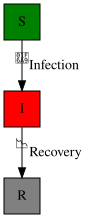

In [3]:
states = [:S, :I, :R] # define the states
transitions = [ :Infection => (:S => :I, :Pattern => 1), :Recovery => (:I => :R, :Rate => 1.0 / average_illness_duration)]
alternatives = [] # this model does not include alternative transitions
SIRStatechart = UnitStateChartF(states, transitions, alternatives)

stateColors = Dict(:S => "green",:I => "red",:R => "gray"); # argument define colors of each state in StateChart
StateCharts.Graph(SIRStatechart, stateColors = stateColors)

define the user_defined rewrite rules: rewrite rules for contacts of Infectives. Note that each transitions_rule has a pair: timer=>rule

In [ ]:
transition_rules = [ ContinuousHazard( 1.0 / (contact_rate * infectivity)) => make_infectious_rule_MultipleObjects(SIRStatechart, [[:S],[:I]],[:I],[[:I],[:I]], :P)]

## Show the model schema

Note: this step is not nessesary. Here it is only used to show the model schema

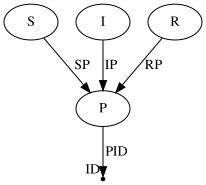

In [5]:
schema_statechart = StateChartABMSchema_MultipleObjects(SIRStatechart,:P)
to_graphviz(schema_statechart |> schemaACSet |> schemaPresent; prog="dot")

## Create and Initialize the Model

In [ ]:
init = radomlyAssignInitialInfectives(StateChartCset_MultipleObjects(SIRStatechart), Int(total_population), Int(frac_initial_infected * total_population))
abm = make_ABM(SIRStatechart,transition_rules,is_schema_singObject=false)

 ## Run the model

In [ ]:
res = run!(abm, init; maxevent=50)

## Plot out the results of each state

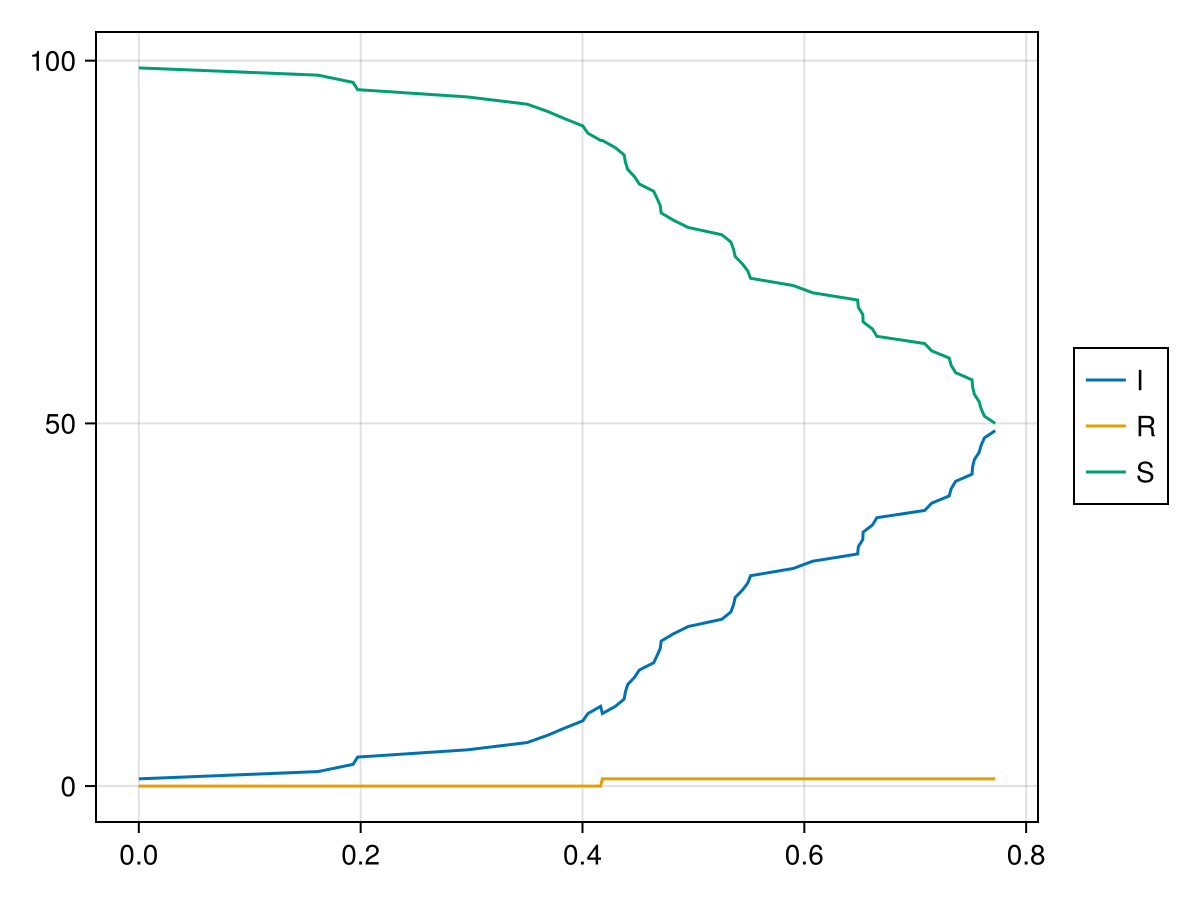

In [14]:
Makie.plot(res; Dict(o=>X->nparts(X,o) for o in states)...)